<a href="https://colab.research.google.com/github/3Frank3/Diabetes-Risk-Prediction-Fairness-Evaluation-and-Causal-Analysis-of-Physical-Activity-Using-PSM/blob/Jolly/02_Modeling%2B%20ANN%20Model%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##02_Modeling

# Load Data

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = X.copy()
df["Diabetes_binary"] = y.values

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

Check the dataset

In [3]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [4]:
df["Diabetes_binary"].value_counts(normalize=True)

,proportion
Diabetes_binary,
0,0.860667
1,0.139333


Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

## Feature scaling (standardization)

Scaling standardizes features so that variables with larger values don’t dominate the model.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##LogisticRegression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR AUC:", average_precision_score(y_test, y_prob_lr))
print("Brier Score:", brier_score_loss(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.95      0.73      0.82     65500
           1       0.31      0.76      0.44     10604

    accuracy                           0.73     76104
   macro avg       0.63      0.74      0.63     76104
weighted avg       0.86      0.73      0.77     76104

Accuracy: 0.731814359297803
ROC AUC: 0.8215200860398352
PR AUC: 0.3989731483344961
Brier Score: 0.1769741062952902


##Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.15
y_pred_rf = (y_prob_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR AUC:", average_precision_score(y_test, y_prob_rf))
print("Brier Score:", brier_score_loss(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81     65500
           1       0.29      0.75      0.42     10604

    accuracy                           0.71     76104
   macro avg       0.62      0.73      0.62     76104
weighted avg       0.85      0.71      0.76     76104

Accuracy: 0.7133527804057606
ROC AUC: 0.7978237788707129
PR AUC: 0.3616684853452844
Brier Score: 0.10356549103046217


##XG Boost

In [9]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.15
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb))
print("Brier Score:", brier_score_loss(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.95      0.73      0.83     65500
           1       0.32      0.77      0.45     10604

    accuracy                           0.74     76104
   macro avg       0.64      0.75      0.64     76104
weighted avg       0.86      0.74      0.78     76104

Accuracy: 0.7384368758540943
ROC AUC: 0.8293604127493297
PR AUC: 0.4282438668255376
Brier Score: 0.09691315260944681


In [10]:
import pandas as pd

importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_table = (
    importance_table
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

importance_table["Importance"] = importance_table["Importance"].round(4)

importance_table

,Feature,Importance
0,HighBP,0.5019
1,GenHlth,0.1328
2,HighChol,0.0802
3,DiffWalk,0.0528
4,BMI,0.0474
5,Age,0.0397
6,HeartDiseaseorAttack,0.0268
7,HvyAlcoholConsump,0.0263
8,CholCheck,0.0215
9,Income,0.0145


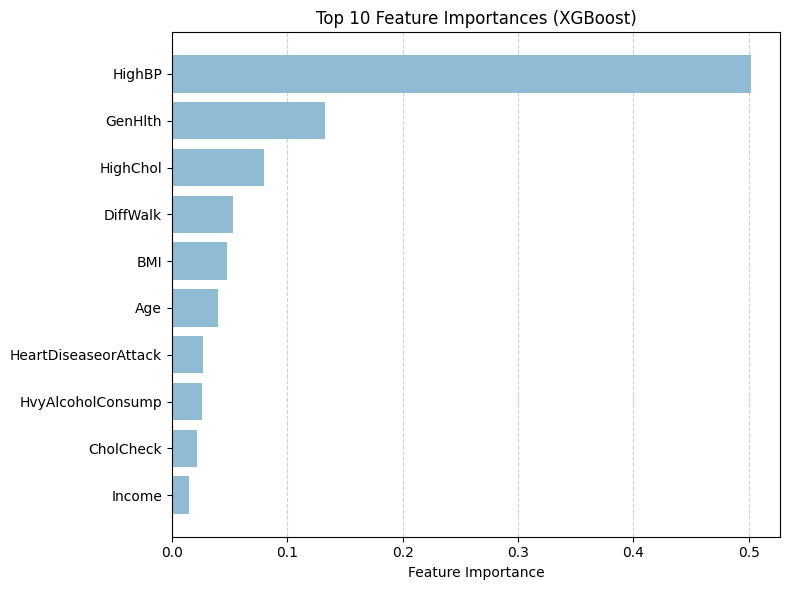

In [11]:
import matplotlib.pyplot as plt

# get importance table (if not already done)
import pandas as pd
importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# select top 10 features
top_n = 10
top_features = importance_table.head(top_n)

# plot
plt.figure(figsize=(8,6))

plt.barh(top_features["Feature"], top_features["Importance"], color="#8FBCD4")

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (XGBoost)")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Result

In [12]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
    recall_score, precision_score, f1_score,
    average_precision_score
)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "PR AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],

    "Recall (Diabetes=1)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "Precision (Diabetes=1)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "F1-score (Diabetes=1)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "Brier Score": [
        brier_score_loss(y_test, y_prob_lr),
        brier_score_loss(y_test, y_prob_rf),
        brier_score_loss(y_test, y_prob_xgb)
    ]
})

results = results.round(3)

results

,Model,Accuracy,ROC AUC,PR AUC,Recall (Diabetes=1),Precision (Diabetes=1),F1-score (Diabetes=1),Brier Score
0,Logistic Regression,0.732,0.822,0.399,0.762,0.311,0.442,0.177
1,Random Forest,0.713,0.798,0.362,0.750,0.293,0.422,0.104
2,XGBoost,0.738,0.829,0.428,0.772,0.319,0.451,0.097


XGBoost,Random Forest,Logistic Regression   PR Curve

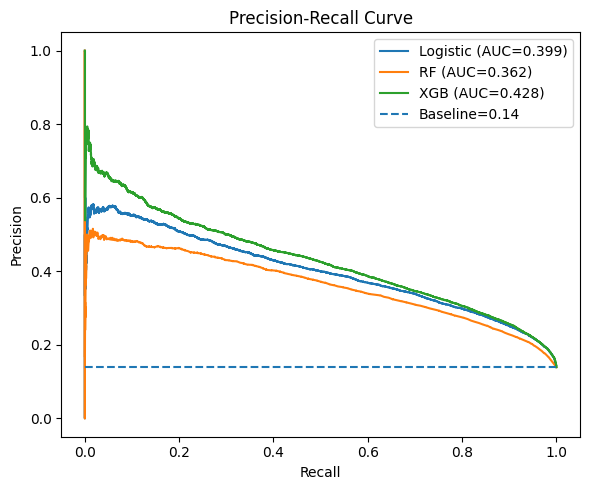

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(6,5))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f"Logistic (AUC={average_precision_score(y_test, y_prob_lr):.3f})")

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f"RF (AUC={average_precision_score(y_test, y_prob_rf):.3f})")

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f"XGB (AUC={average_precision_score(y_test, y_prob_xgb):.3f})")

# baseline
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, linestyles='dashed', label=f"Baseline={baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()

plt.show()

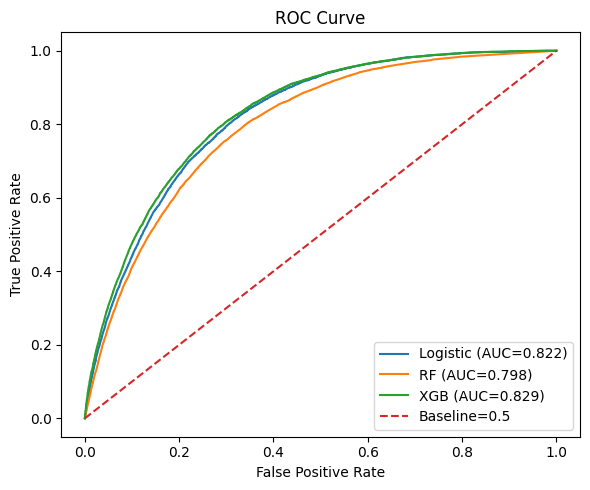

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(6,5))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={roc_auc_score(y_test, y_prob_lr):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})")

# baseline (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', label="Baseline=0.5")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

plt.show()

# Artificial Neural Network (ANN)

In [24]:
# ANN Model 1: Complete Pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

In [25]:
# 1. Initial ANN Model

ann_model1 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 2. Train Model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history1 = ann_model1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8656 - loss: 0.3154 - val_accuracy: 0.8649 - val_loss: 0.3159
Epoch 2/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8666 - loss: 0.3124 - val_accuracy: 0.8662 - val_loss: 0.3151
Epoch 3/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8671 - loss: 0.3117 - val_accuracy: 0.8666 - val_loss: 0.3154
Epoch 4/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8669 - loss: 0.3113 - val_accuracy: 0.8649 - val_loss: 0.3154
Epoch 5/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8673 - loss: 0.3109 - val_accuracy: 0.8666 - val_loss: 0.3145
Epoch 6/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8674 - loss: 0.3107 - val_accuracy: 0.8667 - val_loss: 0.3146
Epoch 7/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.8671 - loss: 0.3106 - val_accuracy: 0.8672 - val_loss: 0.3151
Epoch 8/20
4440/4440 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.8671 - loss: 0

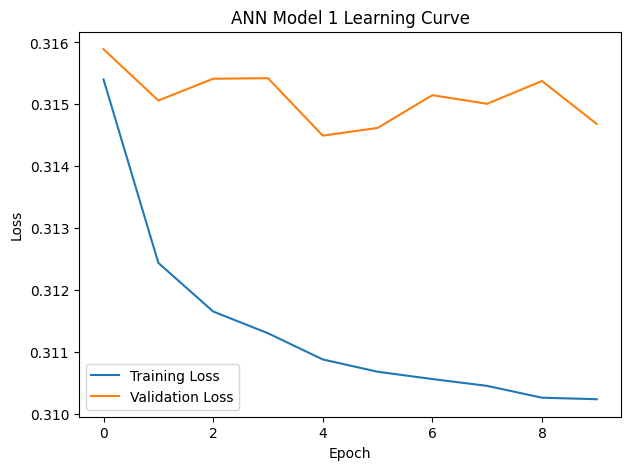

In [29]:
# 3. Learning Curve

plt.figure(figsize=(7, 5))
plt.plot(history1.history["loss"], label="Training Loss")
plt.plot(history1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Model 1 Learning Curve")
plt.legend()
plt.show()

In [30]:
# 4. Predict Probabilities

y_prob_ann1 = ann_model1.predict(X_test_scaled).ravel()

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  


In [31]:
# 5. Threshold Tuning

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_ann1 >= t).astype(int)

    threshold_results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t),
        "F1-score": f1_score(y_test, y_pred_t)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.round(3)

,Threshold,Accuracy,Recall,Precision,F1-score
0,0.10,0.655,0.872,0.271,0.414
1,0.15,0.728,0.788,0.312,0.446
2,0.20,0.778,0.688,0.349,0.463
3,0.25,0.813,0.591,0.387,0.468
4,0.30,0.836,0.497,0.424,0.457
5,0.40,0.859,0.304,0.490,0.375
6,0.50,0.865,0.150,0.561,0.237


In [32]:
# 6. Threshold = 0.15

final_threshold = 0.15
y_pred_ann1 = (y_prob_ann1 >= final_threshold).astype(int)

ann1_results = {
    "Model": "ANN Model 1",
    "Architecture": "32",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_ann1),
    "ROC AUC": roc_auc_score(y_test, y_prob_ann1),
    "PR AUC": average_precision_score(y_test, y_prob_ann1),
    "Recall": recall_score(y_test, y_pred_ann1),
    "Precision": precision_score(y_test, y_pred_ann1),
    "F1-score": f1_score(y_test, y_pred_ann1),
    "Brier Score": brier_score_loss(y_test, y_prob_ann1)
}

pd.DataFrame([ann1_results]).round(3)

,Model,Architecture,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,ANN Model 1,32,0.15,0.728,0.828,0.422,0.788,0.312,0.446,0.097


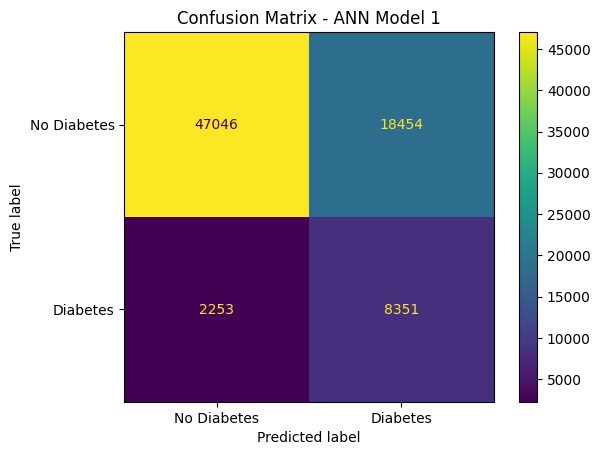

In [33]:
# 7. Confusion Matrix

cm = confusion_matrix(y_test, y_pred_ann1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - ANN Model 1")
plt.show()

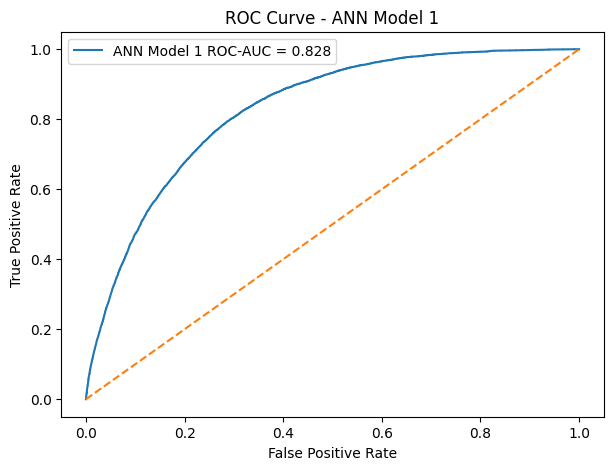

In [34]:
# 8. ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob_ann1)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN Model 1 ROC-AUC = {ann1_results['ROC AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN Model 1")
plt.legend()
plt.show()

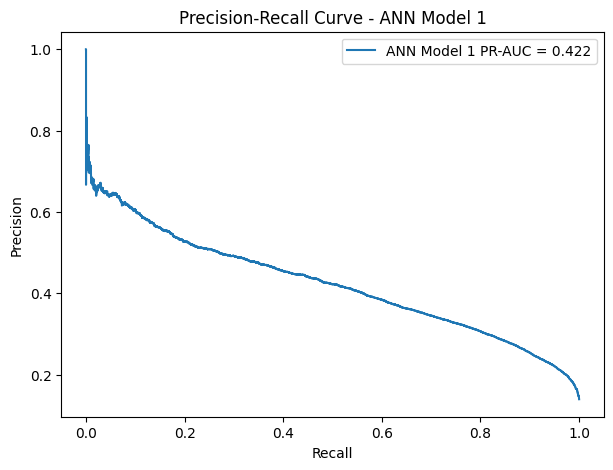

In [35]:
# 9. Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_ann1)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"ANN Model 1 PR-AUC = {ann1_results['PR AUC']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - ANN Model 1")
plt.legend()
plt.show()

In [36]:
# 10. Model 1 Final Table

ann1_table = pd.DataFrame([ann1_results])
ann1_table.round(3)

,Model,Architecture,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,ANN Model 1,32,0.15,0.728,0.828,0.422,0.788,0.312,0.446,0.097
